# Exercise: $\chi^2$ Tests 

This exercuse is divided into two parts, each walking through the full hypothesis-testing workflow:

1. State hypotheses
2. Compute the observed test statistic
3. Build the null distribution
4. Compute the p-value and interpret the result


**A note on the data:**</br>
The datasets used in this exercise are synthetic. The party affiliation counts and the education × news-reading frequency table were both fabricated to produce clean, illustrative examples suitable for a classroom setting — they do not reflect actual survey responses.

If you would like to work with real data, both variables can be extracted from the General Social Survey (GSS), a nationally representative survey of US adults conducted by NORC at the University of Chicago. The GSS has been fielded regularly since 1972 and is publicly available through the [GSS Data Explorer](https://gssdataexplorer.norc.org/). Relevant variables include `partyid` for political party identification and `news` for frequency of newspaper reading. You can build a custom extract, download it in your preferred format (CSV, Stata, SPSS, or R), and substitute the observed counts in the exercise with the real frequencies from your chosen survey year.

---

# Your Name: 
---

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2, chisquare, chi2_contingency

## Part 1: Goodness-of-Fit Test

A **goodness-of-fit** test asks whether the observed distribution of a single categorical variable matches a specific theoretical distribution.

### Problem 1 — Stating the Hypothesis and Computing Expected Counts

A researcher claims that U.S. political party affiliation follows the proportions below:

|Party | Claimed proportion |
|:---|---:|
| Democrat | 30% |
| Republican | 25% |
| Independent | 25% |
| Other | 20% |

A sample of 1,200 individuals yielded the following counts:
- Democrat = 396
- Republican = 312
- Independent = 300
- Other = 192.

1. State the null hypothesis ($H_0$) and the alternative hypothesis ($H_A$).

>**WRITE YOUR ANSWER HERE:**<br>
>- **Null hypothesis ($H_0$):** The population distribution of party affiliation matches the claimed proportions:<br>
>$p_{Democrat}=0.30$,  $p_{Republican}=0.25$,  $p_{Independent}=0.25$,  $p_{Other}=0.20$.
>
>- **Alternative hypothesis ($H_A$):** At least one category's true proportion differs from the claimed value.

2. Compute expected counts.
    - Calculate the expected count for each category under $H_0$.
    - Create a DataFrame displaying:
      - Observed counts
      - Expected counts
      - A column labeled `Difference` defined as (Observed - Expected)
    - Use the party names as the index of the DataFrame.

In [2]:
# WRITE YOUR CODE HERE

sample_size = 1200

party_labels = ['Democrat', 'Republican', 'Independent', 'Other']
party_observed = np.array([396, 312, 300, 192])   # Democrat, Republican, Independent, Other
party_expected_props = np.array([0.30, 0.25, 0.25, 0.20]) # researcher's claimed proportions
party_expected = sample_size * party_expected_props

party_df = pd.DataFrame({
    'Observed': party_observed,
    'Expected': party_expected,
    'Difference (O − E)': party_observed - party_expected
}, index=party_labels)

display(party_df)

,Observed,Expected,Difference (O − E)
Democrat,396,360.0,36.0
Republican,312,300.0,12.0
Independent,300,300.0,0.0
Other,192,240.0,-48.0


3. Visualize the data.
   - Create a bar chart (either horizontal or vertical) comparing observed and expected counts.
       - You can use the DataFrame's built-in `.plot()` method.
   - Include labeled axes and a legend.

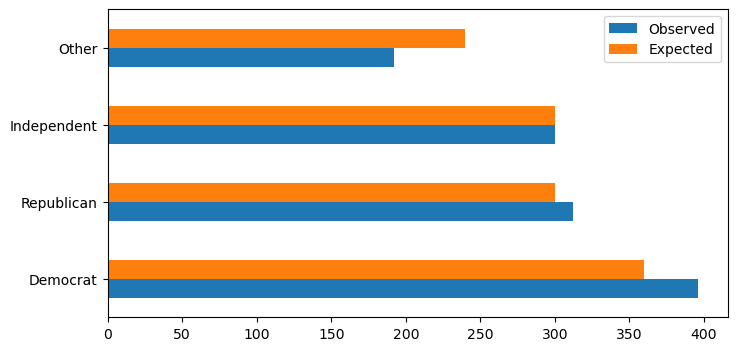

In [3]:
# WRITE YOUR CODE HERE

party_df[["Observed", "Expected"]].plot.barh(figsize=(8, 4));

### Problem 2 — Test Statistic, Null Distribution, and Inference

The chi-squared goodness-of-fit test statistic is:

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

Under the null hypothesis, this statistic follows a $\chi^2$ distribution with $k-1$ degrees of freedom, where $k$ is the number of categories.

1. **Compute the test statistic.**
    - Calculate the chi-squared statistic by summing the contributions from each category.
    - Verify your result using `scipy.stats.chisquare`.

In [4]:
# WRITE YOUR CODE HERE

contributions = (party_observed - party_expected)**2 / party_expected
chi2_stat = contributions.sum()
result = chisquare(f_obs=party_observed, f_exp=party_expected)

print("Chi-squared statistic:")
print(f"   Manually computed         : {chi2_stat:.4f}")
print(f"   From scipy.stats.chisquare: {result.statistic:.4f}")

Chi-squared statistic:
   Manually computed         : 13.6800
   From scipy.stats.chisquare: 13.6800


2. **Plot null distribution.**
   - Plot the chi-squared distribution under $H_0$.
   - Shade the rejection region corresponding to $\alpha=0.05$ and mark the critical value.
   - Mark the observed test statistic with a vertical line on the plot.

Critical value = 7.815


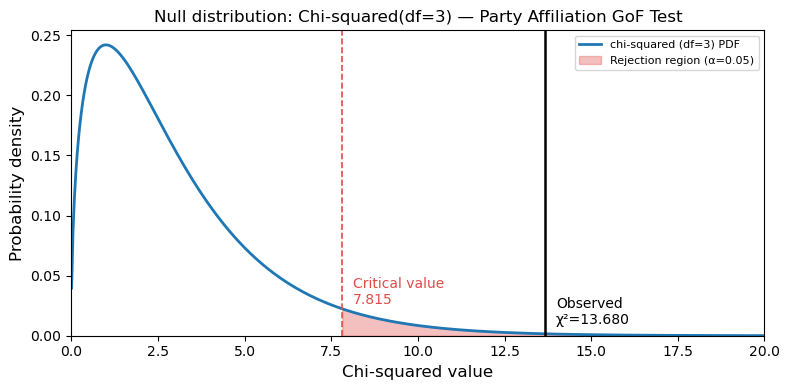

In [5]:
# WRITE YOUR CODE HERE

dof = len(party_labels) - 1
alpha = 0.05

critical_val = chi2.ppf(1 - alpha, df=dof)
print(f"Critical value = {critical_val:.3f}")

x = np.linspace(0.01, 20, 500)
y = chi2.pdf(x, df=dof)

fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(x, y, linewidth=2, label=f'chi-squared (df={dof}) PDF')

x_tail = x[x >= critical_val]
plt.fill_between(x_tail, chi2.pdf(x_tail, df=dof),
                alpha=0.35, color='#E24B4A', label=f'Rejection region (α={alpha})')
ax.axvline(critical_val, color='#E24B4A', linewidth=1.2, linestyle='--')
ax.text(critical_val + 0.3, chi2.pdf(critical_val, df=dof) + 0.004,
        f'Critical value\n{critical_val:.3f}', color='#E24B4A', fontsize=10)
ax.axvline(chi2_stat, color='k', linewidth=1.8)
ax.text(chi2_stat + 0.3, 0.01, f'Observed\nχ²={chi2_stat:.3f}', color='k', fontsize=10)

ax.set_xlabel('Chi-squared value', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Null distribution: Chi-squared(df={dof}) — Party Affiliation GoF Test', fontsize=12)
ax.legend(fontsize=8)
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

3. **Compute the p-value.** The p-value is the probability of observing a test statistic **as extreme or more extreme** than our observed value, assuming the null hypothesis is true:

$$p = P(test\_statistic \geq observed\_statistic)$$

   - Calculate the exact p-value using `scipy.stats.chi2.sf`.
       - The survival function `sf(x)` computes `P(X > x)`, the probability of observing a value greater than $x$ under the null hypothesis.

In [6]:
# WRITE YOUR CODE HERE

p_val = chi2.sf(chi2_stat, df=dof)
print(f"p-value = P(χ²(df={dof}) ≥ {chi2_stat:.2f}) = {p_val:.4f}")

p-value = P(χ²(df=3) ≥ 13.68) = 0.0034


4. **Draw a conclusion.**
   - State your decision at significance level $\alpha = 0.05$.
   - Clearly interpret the result in context.

> **WRITE YOUR ANSWER HERE:**
> 
> P-value is less than 0.05, so we reject the null hypothesis.
> The observed distribution of party affiliation differs significantly from the researcher's proposed 30% / 25% / 25% / 20% split.

## Part 2: Test of Independence

A **test of independence** examines whether two categorical variables are associated, using a two-way contingency table.

We will use the following contingency table of **education level** (4 categories) and **news-reading frequency** (3 categories), based on a sample of size $n = 1,200$.

| Education | Daily | Weekly | Rarely/Never | Total |
|:---|---:|---:|---:|---:|
| Less than HS |  28 |  34 |  58 | 120 |
| HS diploma   |  96 | 130 | 174 | 400 |
| Bachelor's   | 132 | 118 | 110 | 360 |
| Graduate     | 104 |  96 | 120 | 320 |
| Total        | 360 | 378 | 462 | 1200 |

In [7]:
# Contingency Table: Education × News-reading frequency
# Use this for problems in Part 2

obs_matrix = np.array([
    [ 28,  34,  58],   # Less than HS
    [ 96, 130, 174],   # HS diploma
    [132, 118, 110],   # Bachelor's
    [104,  96, 120],   # Graduate
])
row_labels = ['Less than HS', 'HS diploma', "Bachelor's", 'Graduate']
col_labels = ['Daily', 'Weekly', 'Rarely/Never']
n = obs_matrix.sum()

obs_df = pd.DataFrame(obs_matrix, index=row_labels, columns=col_labels)
obs_df.index.name = 'Education'
obs_df

,Daily,Weekly,Rarely/Never
Education,,,
Less than HS,28,34,58
HS diploma,96,130,174
Bachelor's,132,118,110
Graduate,104,96,120


### Problem 1 — Stating the Hypotheses and Computing Expected Counts

1. State the null hypothesis ($H_0$) and the alternative hypothesis ($H_A$).

>**WRITE YOUR ANSWER HERE:**<br>
>- **Null hypothesis ($H_0$):** Education level and news-reading frequency are independent. (Knowing a person's education level tells us nothing about how often they read news.)
>
>- **Alternative hypothesis ($H_A$):** Education level and news-reading frequency are NOT independent. (There IS an association between education and news-reading frequency.)

2. Under the null hypothesis of independence, the expected count for cell $(i, j)$ is:

$$E_{ij} = \frac{(\text{row}_i\text{ total})(\text{col}_j\text{ total})}{n}$$

  - Compute the 4×3 matrix of expected counts (without using `chi2_contingency`). 
  - Check that every expected count is ≥ 5 (required assumption).

In [8]:
# WRITE YOUR CODE HERE

row_totals = obs_matrix.sum(axis=1)   # shape (4,)
col_totals = obs_matrix.sum(axis=0)   # shape (3,)

expected = np.outer(row_totals, col_totals) / n
print(expected)

print(f'\nAre all expected counts >= 5? {(expected >= 5).all()}')

[[ 36.   37.8  46.2]
 [120.  126.  154. ]
 [108.  113.4 138.6]
 [ 96.  100.8 123.2]]

Are all expected counts >= 5? True


### Problem 2 — Test statistic, Null Distribution, and Inference

The chi-squared test of independence test statistic is:

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

1. **Compute the test statistic.**
    - Calculate the chi-squared statistic by summing the contributions cell by cell.
    - Verify your result using `scipy.stats.chi2_contingency`.

In [9]:
# WRITE YOUR CODE HERE

contributions = (obs_matrix - expected)**2 / expected
chi2_stat = contributions.sum()
result = chi2_contingency(obs_matrix)

print("Chi-squared statistic:")
print(f"   Manually computed                : {chi2_stat:.4f}")
print(f"   From scipy.stats.chi2_contingency: {result.statistic:.4f}")

Chi-squared statistic:
   Manually computed                : 25.0979
   From scipy.stats.chi2_contingency: 25.0979


2. **Plot null distribution.** Under the null hypothesis, the test statistic follows a chi-squared distribution where $df = (r - 1)(c - 1)$.
   
  - Calculate the degrees of freedom (df).
  - Plot the chi-squared distribution under $H_0$ over the range [0, 40].
  - Shade the rejection region corresponding to $\alpha=0.05$ and mark the critical value.
  - Mark the observed test statistic with a vertical line on the plot.

Degrees of freedom = 6
Critical value = 12.592


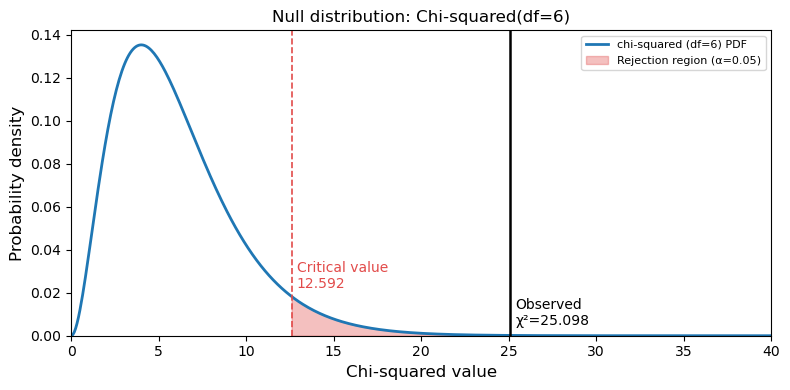

In [10]:
# WRITE YOUR CODE HERE

r, c = obs_matrix.shape
dof = (r - 1) * (c - 1)
print(f"Degrees of freedom = {dof}")

alpha = 0.05
critical_val = chi2.ppf(1 - alpha, df=dof)
print(f"Critical value = {critical_val:.3f}")

x = np.linspace(0.01, 40, 500)
y = chi2.pdf(x, df=dof)

fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(x, y, linewidth=2, label=f'chi-squared (df={dof}) PDF')

x_tail = x[x >= critical_val]
plt.fill_between(x_tail, chi2.pdf(x_tail, df=dof),
                alpha=0.35, color='#E24B4A', label=f'Rejection region (α={alpha})')
ax.axvline(critical_val, color='#E24B4A', linewidth=1.2, linestyle='--')
ax.text(critical_val + 0.3, chi2.pdf(critical_val, df=dof) + 0.004,
        f'Critical value\n{critical_val:.3f}', color='#E24B4A', fontsize=10)
ax.axvline(chi2_stat, color='k', linewidth=1.8)
ax.text(chi2_stat + 0.3, 0.005, f'Observed\nχ²={chi2_stat:.3f}', color='k', fontsize=10)

ax.set_xlabel('Chi-squared value', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Null distribution: Chi-squared(df={dof})', fontsize=12)
ax.legend(fontsize=8)
ax.set_xlim(0, 40)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

3. **Compute the p-value.**
   - Calculate the exact p-value using `scipy.stats.chi2.sf` (survival function = 1 − CDF).

In [11]:
# WRITE YOUR CODE HERE

p_val = chi2.sf(chi2_stat, df=dof)
print(f"p-value = P(χ²(df={dof}) ≥ {chi2_stat:.3f}) = {p_val:.6f}")

p-value = P(χ²(df=6) ≥ 25.098) = 0.000327


4. **Draw a conclusion.**
   - Compare the p-value to $\alpha = 0.05$ and state the reject or fail-to-reject decision.
   - Clearly interpret the result in context.

> **WRITE YOUR ANSWER HERE:**
> 
> P-value is less than 0.05, so we reject the null hypothesis.
> The data provide strong evidence that education level and news-reading frequency are associated. Respondents with higher levels of education read the news daily more often than expected, while those without a high school diploma report reading the news rarely or never more often than expected.

---
## Summary

### Part 1: Goodness-of-Fit

| Step | Result |
|---|---|
| **Hypotheses** | $H_0$: proportions match 30/25/25/20; $H_A$: at least one differs |
| **Test statistic** | $\chi^2(3) =$ **13.68** computed from $\sum(O_i−E_i)^²/E_i$ |
| **Null distribution** | $\chi^2(k−1) = \chi^2(3)$, critical value = **7.815** |
| **p-value** | $P(\chi^2(3) \geq 13.68) ≈$ **0.0034** |
| **Decision** | Reject $H_0$ — party affiliation proportion doesn't match the expected proportion|

### Part 2: Test of Independence

| Step | Result |
|---|---|
| **Hypotheses** | $H_0$: education and news-reading frequency are not related; $H_A$: association exists |
| **Expected counts** | $E_{ij} = (\text{row}_i\text{ total} \times \text{col}_j\text{ total}) / n$; all $\geq 5$ ✓ |
| **Test statistic** | $\chi^2(6) =$ **25.098** |computed from $\sum(O_{ij}−E_{ij})^²/E_{ij}$
| **Null distribution** | $\chi^2((r-1)(c-1)) = \chi^2(6)$, critical value = **12.592** |
| **p-value** | $P(\chi^2(6) \geq 25.098) ≈$ **0.000327** |
| **Decision** | Reject $H_0$ — strong evidence of association |